### Imports

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os # look through folders
import skimage.io as io # for image processing
import numpy as np # v. useful for everything! esp when dealing with lists.
import shutil # useful for moving and copying files around.
from copy import deepcopy # useful for creating deepcopies so you don't affect original things.
import matplotlib.pyplot as plt # useful for plotting
from skimage import measure # useful for image processing
import matplotlib.image as mpimg # useful for saving images
import tqdm # for progress bars
from pathlib import Path # Reading and moving and creating directories

### Data

In [4]:
# Path to folder containing all images
pth = '/content/Specimen_labels'
files = os.listdir(pth) # gets all files in the path.

### Functions

In [5]:
def find_and_filter_contours(image,min_yrange=4,min_xrange=10,min_length=5):
    # This code finds contours and filters for contours of a certain length (number of points on the line)

    contours = measure.find_contours(image, 0.8)
    contours_refined = []

    for c in contours:
        rng_y = max(c[:,0]) - min(c[:,0])
        rng_x = max(c[:,1]) - min(c[:,1])

        if (rng_x > min_xrange) and (len(c[:,0])>min_length) and (rng_y > min_yrange):
            contours_refined.append(c)

    min_point = min([int(min(c[:,0])) for c in contours_refined])

    max_point = max([int(max(c[:,0])) for c in contours_refined])


    return contours_refined,min_point,max_point

In [6]:
def split_image_into_three(image):
    n = np.shape(image)[0]
    img1 = image[:round(n/3),:]
    img2 = image[round(n/3):round(2*n/3),:]
    img3 = image[round(2*n/3):,:]
    return img1,img2,img3

In [7]:
def cut_and_merge_labels(image1,image2,miny1,maxy1,miny2,maxy2,leeway=0.01):
    a,b1 = np.shape(image1)[:2]
    eps = a*leeway
    new_image1 = image1[np.max([0,round(miny1-eps)]):np.min([round(maxy1+eps),a]),:]

    a,b2 = np.shape(image2)[:2]
    eps = a*leeway
    new_image2 = image2[np.max([0,round(miny2-eps)]):np.min([round(maxy2+eps),a]),:]

    merged_image = np.zeros((np.shape(new_image1)[0]+np.shape(new_image2)[0],max([b1,b2]),3),dtype=np.uint8)
    merged_image[:np.shape(new_image1)[0],:,:] = new_image1
    merged_image[np.shape(new_image1)[0]:,:,:] = new_image2

    return merged_image

In [48]:
def get_new_image(image_path):
    image_grey = io.imread(image_path,as_gray=True)
    I1,I2,I3 = split_image_into_three(image_grey)
    image_col = io.imread(image_path,as_gray=False)
    I1c,I2c,I3c = split_image_into_three(image_col)
    try:
      _,mn1,mx1 = find_and_filter_contours(I2,min_xrange=np.shape(I2)[1]*0.025,min_length=15)
      _,mn2,mx2 = find_and_filter_contours(I3,min_xrange=np.shape(I3)[1]*0.025,min_length=15)
    except:
      mn1 = 0
      mx1 = np.shape(I2)[0]
      mn2 = 0
      mx2 = np.shape(I3)[0]
    merged = cut_and_merge_labels(I2c,I3c,mn1,mx1,mn2,mx2)
    return merged

### Test 1 - Contours

In [9]:
img = io.imread(pth+'/'+files[0],as_gray=True)
I1,I2,I3 = split_image_into_three(img)

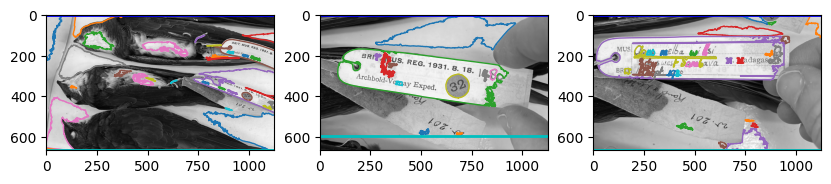

In [10]:
fig,ax = plt.subplots(1,3,figsize=(10,7))

a,b = np.shape(img)

ax[0].imshow(I1,cmap='gray')
contours,mn,mx = find_and_filter_contours(I1,min_xrange=b*0.025,min_length=15)
for c in contours:
    ax[0].plot(c[:,1],c[:,0],lw=1)
ax[0].plot([0,b-5],[mn,mn],'-b',lw=2)
ax[0].plot([0,b-5],[mx,mx],'-c',lw=2)

ax[1].imshow(I2,cmap='gray')
contours,mn,mx = find_and_filter_contours(I2,min_xrange=b*0.025,min_length=15)
for c in contours:
    ax[1].plot(c[:,1],c[:,0],lw=1)
ax[1].plot([0,b-5],[mn,mn],'-b',lw=2)
ax[1].plot([0,b-5],[mx,mx],'-c',lw=2)

ax[2].imshow(I3,cmap='gray')
contours,mn,mx = find_and_filter_contours(I3,min_xrange=b*0.025,min_length=15)
for c in contours:
    ax[2].plot(c[:,1],c[:,0],lw=1)
ax[2].plot([0,b-5],[mn,mn],'-b',lw=2)
ax[2].plot([0,b-5],[mx,mx],'-c',lw=2)

### Test 2 - Image Cropping / Merging

In [11]:
merged = get_new_image(pth+'/'+files[0])

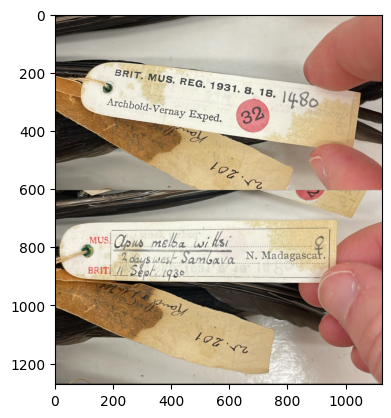

In [12]:
fig,ax = plt.subplots()
ax.imshow(merged)

In [16]:
folder_to_save='/content/Cropped_images'


In [17]:
for f in tqdm.tqdm(files[:3]):
    merged = get_new_image(pth+'/'+f)
    mpimg.imsave(folder_to_save+'/'+f[:-3]+'png', merged)

100%|██████████| 3/3 [00:02<00:00,  1.05it/s]


In [28]:
folders=os.listdir('/content/drive/MyDrive/Madagascar birds/Final images organised/Specimen label images')

In [32]:
folder_path='/content/drive/MyDrive/Madagascar birds/Final images organised/Specimen label images'

In [29]:
folders

['Sterna dougalli arideensis',
 'Tringa hypoleucos',
 'Treron australis xenia',
 'Tyto alba affinis',
 'Thalassornis leucomatus insularis',
 'Thalasseus bergii bergii',
 'Xenus cinereus cinereus',
 'Threskiornis aethiopica bernioni',
 'Tachornis',
 'Streptopelia picturata picturata',
 'Sterna hirundo',
 'Zoonavera grandidieri',
 'Apus apus balstoni',
 'Acridotheres tristis',
 'Anhinga rufa rubini',
 'Apus melba willsi',
 'Amaurornis olivieri',
 'Coracina cinerea',
 'Asio caphensis hova',
 'Ardea humbloti',
 'Charadrius tricollaris bifrontatus',
 'Cisticola cherina',
 'Charadrius hiaticula tundrae',
 'Charadrius marginatus tenellus',
 'Coracopsis vasa vasa',
 'Agapornis cana cana',
 'Bernieria madagascariensis',
 'Circus maillardi macroscelis',
 'Arenaria interpres interpres',
 'Butorides striatus rutenbugi',
 'Bulbulcus ibis ibis',
 'Centropus toulou toulou',
 'Ardeola ralloides ralloides',
 'Caprimulgus madagascariensis',
 'Charadrius pecuarius',
 'Charadrius leschenaultii',
 'Coracop

In [30]:
len(folders)

97

In [ ]:
OUTPUT_DIR = DATA_DIR / folder
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [31]:
DATA_DIR=Path('/content/drive/MyDrive/Madagascar birds/Final cropped images')

In [34]:
for folder in tqdm.tqdm(folders):
    OUTPUT_DIR = DATA_DIR / folder
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    folder_files=os.listdir(folder_path+'/'+folder)
    for f in folder_files:
        merged = get_new_image(folder_path+'/'+folder+'/'+f)
        mpimg.imsave(OUTPUT_DIR / f, merged)

 16%|█▋        | 16/97 [02:03<10:26,  7.74s/it]


ValueError: min() iterable argument is empty

In [35]:
errors = []
for folder in tqdm.tqdm(folders[16:]):
    OUTPUT_DIR = DATA_DIR / folder
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    folder_files=os.listdir(folder_path+'/'+folder)
    try:
      for f in folder_files:
          merged = get_new_image(folder_path+'/'+folder+'/'+f)
          mpimg.imsave(OUTPUT_DIR / f, merged)
    except:
      errors.append([folder,f])

100%|██████████| 81/81 [10:55<00:00,  8.09s/it]


In [38]:
folder2 = os.listdir(DATA_DIR)

In [39]:
len(folder2)

96

In [40]:
len(folders)

97

In [41]:
for p in folders:
  if p not in folder2:
    print(p)

Sterna dougalli arideensis


In [42]:
folder = 'Sterna dougalli arideensis'
OUTPUT_DIR = DATA_DIR / folder
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
folder_files=os.listdir(folder_path+'/'+folder)
try:
  for f in folder_files:
      merged = get_new_image(folder_path+'/'+folder+'/'+f)
      mpimg.imsave(OUTPUT_DIR / f, merged)
except:
  errors.append([folder,f])

In [43]:
errors

[['Amaurornis olivieri', '1931.8.18.1791.JPG'],
 ['Bulbulcus ibis ibis', '1931.8.18.130.JPG'],
 ['Fulica cristata', '1931.8.18.1144.JPG']]

In [51]:
for i in range(3):
  folder =errors[i][0]
  f = errors[i][1]
  OUTPUT_DIR = DATA_DIR / folder
  merged = get_new_image(folder_path+'/'+folder+'/'+f)
  mpimg.imsave(OUTPUT_DIR / f, merged)

In [45]:
img = io.imread(folder_path+'/'+folder+'/'+f,as_gray=True)

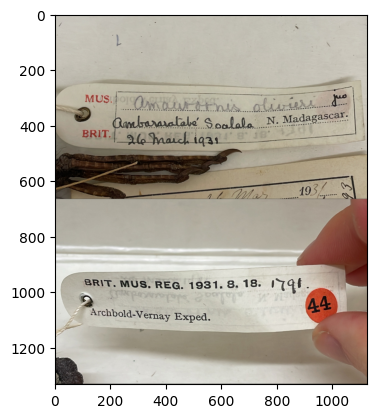

In [50]:
fig,ax = plt.subplots()
ax.imshow(merged)

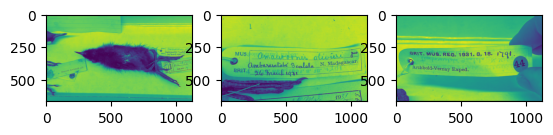

In [47]:
I1,I2,I3 = split_image_into_three(img)
fig,ax = plt.subplots(1,3)
ax[0].imshow(I1)
ax[1].imshow(I2)
ax[2].imshow(I3)